# Bootstrap Validation — Pipeline Stability

Tests whether the nb21 pipeline results reflect real signal or noise-fitting on a small dataset (n=759).

For each of **B=25 bootstrap resamples** of the training set, the full pipeline runs independently from scratch: Optuna tuning → CV importance → genre consolidation → forward selection → Optuna re-tune. Test AUC and Brier score are evaluated on the **fixed held-out test set** (never resampled).

**What this answers:** If bootstrap AUC distributions are consistently above the stratified baseline and clustered near the nb21 result, the pipeline found real signal. If distributions are wide or close to baseline, noise-fitting is a concern.

**Simplifications vs nb21** (applied equally to every iteration — does not bias comparisons):
- Optuna: 10 trials instead of 30
- Re-tune: `n_peak` only
- Centrality ablation: skipped

**Models:** CatBoost · XGBoost · Random Forest · Stratified Baseline  
Results saved to `bootstrap_results.pkl` after every iteration — safe against kernel shutdowns.

In [4]:
import warnings
warnings.filterwarnings('ignore')

import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import shap
import optuna
from optuna.samplers import TPESampler
optuna.logging.set_verbosity(optuna.logging.WARNING)

from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance
from sklearn.metrics import roc_auc_score, brier_score_loss
from sklearn.model_selection import train_test_split, StratifiedKFold

from xgboost import XGBClassifier
from catboost import CatBoostClassifier

In [5]:
B            = 25
N_TRIALS     = 10
LAM          = 0.3
N_SPLITS     = 5
MIN_N        = 5
RANDOM_STATE = 42

BOOT_MODELS = ['CatBoost', 'XGBoost', 'Random Forest']

# nb21 single-run test AUC — reference lines on histograms
NB21_AUC = {
    'CatBoost':      0.7533,
    'XGBoost':       0.7742,
    'Random Forest': 0.7671,
}

df = pd.read_csv('df_artists_final.csv', index_col=0).reset_index()
X  = df.drop(columns=['top_20_hitmaker'])
y  = df['top_20_hitmaker']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

print(f'Train: {X_train.shape}  Test: {X_test.shape}')
print(f'Class balance (train): {y_train.mean():.3f} hitmaker')

Train: (607, 26)  Test: (152, 26)
Class balance (train): 0.432 hitmaker


## Helper functions

`build_model`, `make_optuna_objective` — identical to nb21, restricted to CatBoost, XGBoost, Random Forest.  
`compute_cv_importance`, `genre_consolidate`, `forward_select`, `run_pipeline_one_model` — accept `skf` explicitly so they operate correctly on each bootstrap sample.

In [6]:
def build_model(name, params):
    if name == 'Random Forest':
        return RandomForestClassifier(
            n_estimators=params['n_estimators'],
            max_depth=params.get('max_depth'),
            min_samples_leaf=params.get('min_samples_leaf', 1),
            max_features=params.get('max_features', 'sqrt'),
            class_weight='balanced',
            random_state=RANDOM_STATE, n_jobs=-1,
        )
    elif name == 'XGBoost':
        return XGBClassifier(
            n_estimators=params['n_estimators'],
            learning_rate=params['learning_rate'],
            max_depth=params.get('max_depth', 3),
            min_child_weight=params.get('min_child_weight', 1),
            gamma=params.get('gamma', 0.0),
            subsample=params.get('subsample', 0.8),
            colsample_bytree=params.get('colsample_bytree', 0.8),
            reg_alpha=params.get('reg_alpha', 0.0),
            reg_lambda=params.get('reg_lambda', 1.0),
            random_state=RANDOM_STATE, eval_metric='logloss', verbosity=0,
        )
    elif name == 'CatBoost':
        return CatBoostClassifier(
            iterations=params['n_estimators'],
            learning_rate=params['learning_rate'],
            depth=params.get('depth', 4),
            l2_leaf_reg=params.get('l2_leaf_reg', 3.0),
            random_strength=params.get('random_strength', 1.0),
            border_count=params.get('border_count', 128),
            random_seed=RANDOM_STATE, verbose=0,
        )
    raise ValueError(f'Unknown model: {name}')


def make_optuna_objective(name, X, y, lam, skf):
    def objective(trial):
        if name == 'Random Forest':
            params = {
                'n_estimators':     trial.suggest_int('n_estimators', 100, 500),
                'max_depth':        trial.suggest_int('max_depth', 2, 15),
                'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 20),
                'max_features':     trial.suggest_categorical('max_features',
                                        ['sqrt', 'log2', 0.3, 0.5, 0.7]),
            }
        elif name == 'XGBoost':
            params = {
                'n_estimators':     trial.suggest_int('n_estimators', 50, 500),
                'learning_rate':    trial.suggest_float('learning_rate', 0.005, 0.3, log=True),
                'max_depth':        trial.suggest_int('max_depth', 2, 8),
                'min_child_weight': trial.suggest_int('min_child_weight', 1, 20),
                'gamma':            trial.suggest_float('gamma', 0.0, 5.0),
                'subsample':        trial.suggest_float('subsample', 0.5, 1.0),
                'colsample_bytree': trial.suggest_float('colsample_bytree', 0.3, 1.0),
                'reg_alpha':        trial.suggest_float('reg_alpha', 1e-4, 10.0, log=True),
                'reg_lambda':       trial.suggest_float('reg_lambda', 1e-4, 10.0, log=True),
            }
        elif name == 'CatBoost':
            params = {
                'n_estimators':    trial.suggest_int('n_estimators', 50, 500),
                'learning_rate':   trial.suggest_float('learning_rate', 0.005, 0.3, log=True),
                'depth':           trial.suggest_int('depth', 2, 8),
                'l2_leaf_reg':     trial.suggest_float('l2_leaf_reg', 0.5, 10.0, log=True),
                'random_strength': trial.suggest_float('random_strength', 0.1, 5.0, log=True),
                'border_count':    trial.suggest_int('border_count', 32, 255),
            }
        fold_val, fold_tr = [], []
        for tr_idx, val_idx in skf.split(X, y):
            X_tr, X_val = X.iloc[tr_idx], X.iloc[val_idx]
            y_tr, y_val = y.iloc[tr_idx], y.iloc[val_idx]
            m = build_model(name, params)
            try:
                m.fit(X_tr, y_tr)
                fold_val.append(roc_auc_score(y_val, m.predict_proba(X_val)[:, 1]))
                fold_tr.append(roc_auc_score(y_tr,  m.predict_proba(X_tr)[:, 1]))
            except Exception:
                fold_val.append(np.nan); fold_tr.append(np.nan)
        val_auc = np.nanmean(fold_val)
        return val_auc - lam * (np.nanmean(fold_tr) - val_auc)
    return objective

In [7]:
def compute_cv_importance(name, X_tr, y_tr, params, skf):
    fold_importances = []
    for tr_idx, val_idx in skf.split(X_tr, y_tr):
        X_f, X_v = X_tr.iloc[tr_idx], X_tr.iloc[val_idx]
        y_f, y_v = y_tr.iloc[tr_idx], y_tr.iloc[val_idx]
        m = build_model(name, params)
        try:
            m.fit(X_f, y_f)
            try:
                explainer = shap.TreeExplainer(m)
                sv = explainer.shap_values(X_v)
                if isinstance(sv, list): sv = sv[1]
                elif sv.ndim == 3:       sv = sv[:, :, 1]
                fold_importances.append(np.abs(sv).mean(axis=0))
            except Exception:
                perm = permutation_importance(m, X_v, y_v, n_repeats=5,
                           random_state=RANDOM_STATE, scoring='roc_auc')
                fold_importances.append(perm.importances_mean)
        except Exception:
            pass
    if not fold_importances:
        return pd.DataFrame({'Feature': X_tr.columns,
                             'Importance': np.zeros(X_tr.shape[1])})
    mean_imp = np.mean(fold_importances, axis=0)
    return (pd.DataFrame({'Feature': X_tr.columns, 'Importance': mean_imp})
              .sort_values('Importance', ascending=False).reset_index(drop=True))


def genre_consolidate(X_tr, X_te, perm_df):
    all_genre_cols = [c for c in X_tr.columns if c.startswith('artist_genre_')]
    genre_imp  = perm_df.set_index('Feature')['Importance']
    genre_vals = genre_imp[[c for c in all_genre_cols if c in genre_imp.index]]
    high = [c for c in all_genre_cols if genre_imp.get(c, 0) > genre_vals.mean()]
    low  = [c for c in all_genre_cols if c not in high]
    X_tr_c = X_tr.drop(columns=low).copy()
    X_te_c = X_te.drop(columns=low).copy()
    if low:
        X_tr_c['artist_genre_other'] = (X_tr[low].sum(axis=1) > 0).astype(int)
        X_te_c['artist_genre_other'] = (X_te[low].sum(axis=1) > 0).astype(int)
    return X_tr_c, X_te_c


def forward_select(name, X_tr, y_tr, params, skf):
    perm_df = compute_cv_importance(name, X_tr, y_tr, params, skf)
    feature_order = [f for f in perm_df['Feature'] if f in X_tr.columns]
    if 'artist_genre_other' in X_tr.columns and 'artist_genre_other' not in feature_order:
        feature_order.append('artist_genre_other')
    sel_results = []
    for n in range(min(3, len(feature_order)), len(feature_order) + 1):
        feats = feature_order[:n]
        fold_val, fold_tr = [], []
        for tr_idx, val_idx in skf.split(X_tr[feats], y_tr):
            X_f, X_v = X_tr[feats].iloc[tr_idx], X_tr[feats].iloc[val_idx]
            y_f, y_v = y_tr.iloc[tr_idx], y_tr.iloc[val_idx]
            m = build_model(name, params)
            try:
                m.fit(X_f, y_f)
                fold_val.append(roc_auc_score(y_v, m.predict_proba(X_v)[:, 1]))
                fold_tr.append(roc_auc_score(y_f, m.predict_proba(X_f)[:, 1]))
            except Exception:
                fold_val.append(np.nan); fold_tr.append(np.nan)
        val_auc = np.nanmean(fold_val)
        sel_results.append({'n_features': n, 'CV AUC': val_auc,
                            'Overfit Gap': np.nanmean(fold_tr) - val_auc})
    return feature_order, pd.DataFrame(sel_results).set_index('n_features')


def run_pipeline_one_model(name, X_tr, y_tr, X_te, y_te, seed):
    skf_inner = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=seed)

    imp      = SimpleImputer(strategy='median')
    X_tr_imp = pd.DataFrame(imp.fit_transform(X_tr), columns=X_tr.columns, index=X_tr.index)
    X_te_imp = pd.DataFrame(imp.transform(X_te),     columns=X_te.columns, index=X_te.index)

    s1 = optuna.create_study(direction='maximize', sampler=TPESampler(seed=seed))
    s1.optimize(make_optuna_objective(name, X_tr_imp, y_tr, LAM, skf_inner),
                n_trials=N_TRIALS, show_progress_bar=False)
    params_full = s1.best_params

    perm_df = compute_cv_importance(name, X_tr_imp, y_tr, params_full, skf_inner)

    X_tr_c, X_te_c = genre_consolidate(X_tr_imp, X_te_imp, perm_df)

    feature_order, df_sel = forward_select(name, X_tr_c, y_tr, params_full, skf_inner)

    n_peak = max(int(df_sel['CV AUC'].idxmax()), MIN_N)
    feats  = feature_order[:n_peak]
    s2 = optuna.create_study(direction='maximize', sampler=TPESampler(seed=seed))
    s2.optimize(make_optuna_objective(name, X_tr_c[feats], y_tr, LAM, skf_inner),
                n_trials=N_TRIALS, show_progress_bar=False)
    params_final = s2.best_params

    model = build_model(name, params_final)
    model.fit(X_tr_c[feats], y_tr)
    y_proba = model.predict_proba(X_te_c[feats])[:, 1]

    return {
        'test_auc':   roc_auc_score(y_te, y_proba),
        'brier':      brier_score_loss(y_te, y_proba),
        'n_features': n_peak,
    }

## Bootstrap loop

B=25 independent pipeline iterations. Saved to `bootstrap_results.pkl` after every iteration.

In [5]:
results = {name: {'test_auc': [], 'brier': [], 'n_features': []} for name in BOOT_MODELS}
results['Baseline'] = {'test_auc': [], 'brier': []}

rng = np.random.default_rng(RANDOM_STATE)

for b in range(B):
    seed     = RANDOM_STATE + b
    boot_idx = rng.choice(len(X_train), size=len(X_train), replace=True)
    X_tr_b   = X_train.iloc[boot_idx].reset_index(drop=True)
    y_tr_b   = y_train.iloc[boot_idx].reset_index(drop=True)

    print(f'[{b+1:02d}/{B}] ', end='', flush=True)

    for name in BOOT_MODELS:
        print(f'{name}... ', end='', flush=True)
        try:
            res = run_pipeline_one_model(name, X_tr_b, y_tr_b, X_test, y_test, seed)
            results[name]['test_auc'].append(res['test_auc'])
            results[name]['brier'].append(res['brier'])
            results[name]['n_features'].append(res['n_features'])
            print(f'AUC={res["test_auc"]:.3f} n={res["n_features"]} | ', end='', flush=True)
        except Exception as e:
            print(f'ERROR({e}) | ', end='', flush=True)
            for k in ('test_auc', 'brier', 'n_features'):
                results[name][k].append(np.nan)

    dummy = DummyClassifier(strategy='stratified', random_state=seed)
    dummy.fit(X_tr_b, y_tr_b)
    dummy_proba = dummy.predict_proba(X_test)[:, 1]
    results['Baseline']['test_auc'].append(roc_auc_score(y_test, dummy_proba))
    results['Baseline']['brier'].append(brier_score_loss(y_test, dummy_proba))
    print(f'Baseline={results["Baseline"]["test_auc"][-1]:.3f}')

    with open('bootstrap_results.pkl', 'wb') as f:
        pickle.dump(results, f)

print('\nDone. Results saved to bootstrap_results.pkl')

[01/25] CatBoost... AUC=0.708 n=12 | XGBoost... AUC=0.674 n=12 | Random Forest... AUC=0.731 n=10 | Baseline=0.492
[02/25] CatBoost... AUC=0.728 n=14 | XGBoost... AUC=0.743 n=12 | Random Forest... AUC=0.761 n=13 | Baseline=0.506
[03/25] CatBoost... AUC=0.743 n=9 | XGBoost... AUC=0.752 n=13 | Random Forest... AUC=0.765 n=10 | Baseline=0.501
[04/25] CatBoost... AUC=0.750 n=16 | XGBoost... AUC=0.757 n=13 | Random Forest... AUC=0.769 n=14 | Baseline=0.511
[05/25] CatBoost... AUC=0.703 n=14 | XGBoost... AUC=0.724 n=10 | Random Forest... AUC=0.746 n=13 | Baseline=0.502
[06/25] CatBoost... AUC=0.711 n=13 | XGBoost... AUC=0.749 n=8 | Random Forest... AUC=0.760 n=12 | Baseline=0.522
[07/25] CatBoost... AUC=0.722 n=8 | XGBoost... AUC=0.766 n=9 | Random Forest... AUC=0.732 n=9 | Baseline=0.463
[08/25] CatBoost... AUC=0.605 n=5 | XGBoost... AUC=0.721 n=8 | Random Forest... AUC=0.729 n=13 | Baseline=0.519
[09/25] CatBoost... AUC=0.729 n=10 | XGBoost... AUC=0.731 n=12 | Random Forest... AUC=0.732 n=1

## Results

**Reading the histograms:**
- Dashed line = bootstrap mean · Shaded band = 90% CI · Dotted line = nb21 single-run AUC
- Bootstrap mean ≈ nb21 dotted line → single-run result is reproducible; pipeline is stable
- nb21 dotted line above 90% CI → single-run was optimistically biased
- All model distributions clearly above Baseline → real signal, not noise

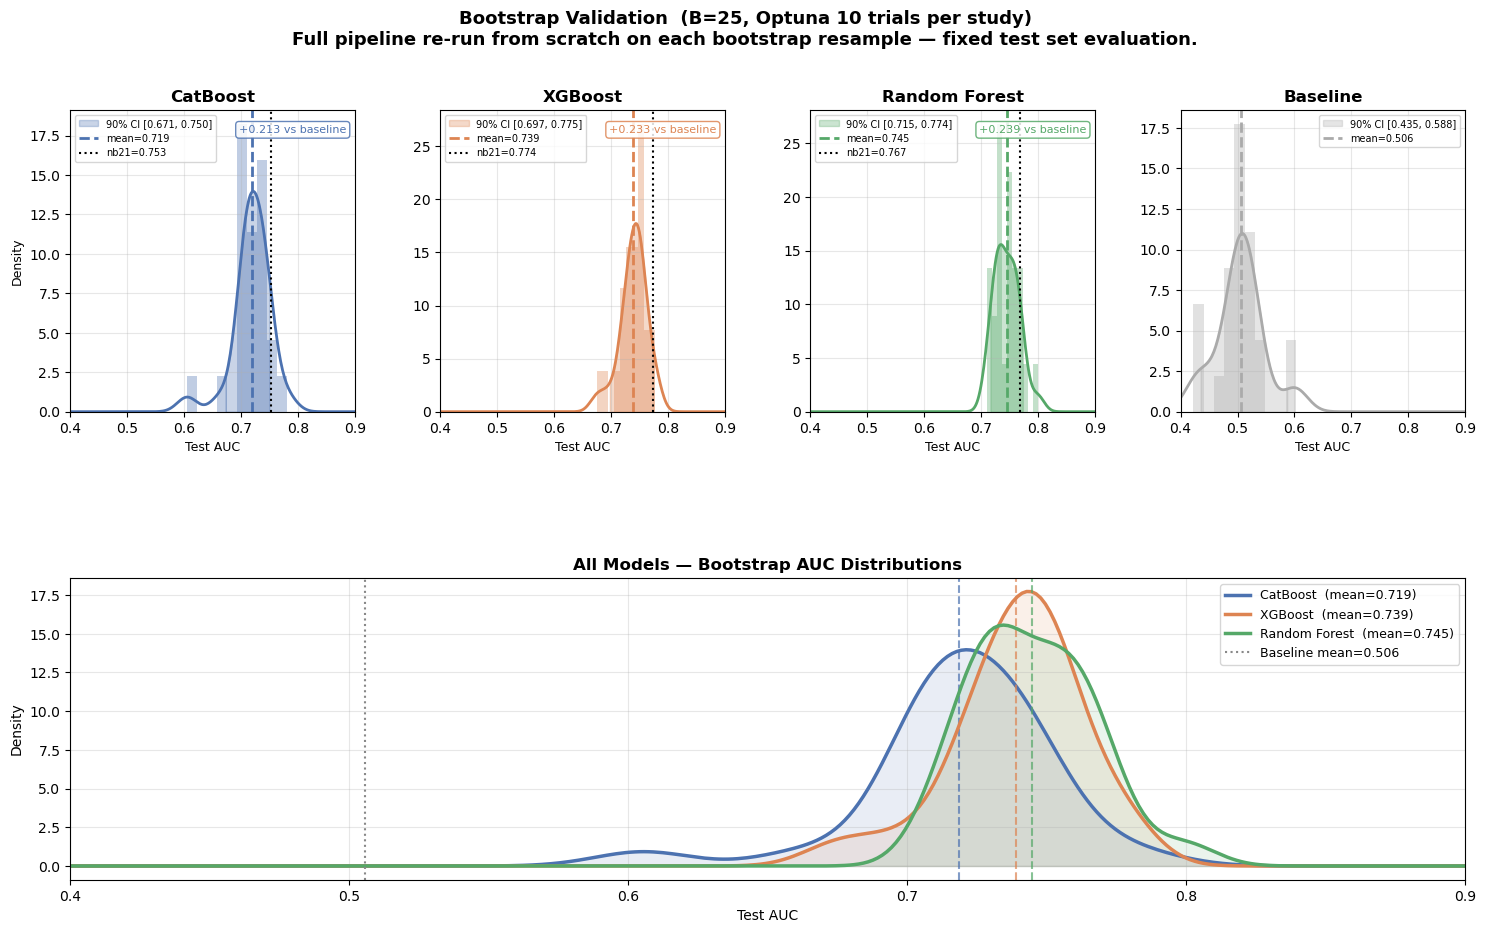

In [8]:
from scipy.stats import gaussian_kde
import matplotlib.gridspec as gridspec

with open('bootstrap_results.pkl', 'rb') as f:
    results = pickle.load(f)

all_names = BOOT_MODELS + ['Baseline']
palette = {
    'CatBoost':      '#4C72B0',
    'XGBoost':       '#DD8452',
    'Random Forest': '#55A868',
    'Baseline':      '#aaaaaa',
}

metric = 'test_auc'
xlim   = (0.40, 0.90)
x_grid = np.linspace(*xlim, 300)

baseline_aucs = [v for v in results['Baseline'][metric] if not np.isnan(v)]
baseline_mean = np.mean(baseline_aucs)

fig = plt.figure(figsize=(18, 10))
gs  = gridspec.GridSpec(2, 4, figure=fig, hspace=0.55, wspace=0.30)
top_axes    = [fig.add_subplot(gs[0, col]) for col in range(4)]
ax_combined = fig.add_subplot(gs[1, :])

fig.suptitle(
    f'Bootstrap Validation  (B={B}, Optuna {N_TRIALS} trials per study)\n'
    'Full pipeline re-run from scratch on each bootstrap resample — fixed test set evaluation.',
    fontsize=13, fontweight='bold')

# ── Row 1: individual panels ──────────────────────────────────────────
for col, name in enumerate(all_names):
    ax   = top_axes[col]
    vals = [v for v in results[name][metric] if not np.isnan(v)]
    if not vals:
        ax.set_title(f'{name}\n(no data)'); continue

    color = palette[name]
    mu    = np.mean(vals)
    p5    = np.percentile(vals, 5)
    p95   = np.percentile(vals, 95)

    # Histogram
    ax.hist(vals, bins=10, color=color, alpha=0.35, density=True)

    # KDE
    kde   = gaussian_kde(vals, bw_method='scott')
    y_kde = kde(x_grid)

    ax.plot(x_grid, y_kde, color=color, lw=2.0)

    # 90% CI shading
    mask = (x_grid >= p5) & (x_grid <= p95)
    ax.fill_between(x_grid[mask], y_kde[mask], alpha=0.30, color=color,
                    label=f'90% CI [{p5:.3f}, {p95:.3f}]')

    # Mean + nb21 reference
    ax.axvline(mu, color=color, lw=2.0, linestyle='--', label=f'mean={mu:.3f}')
    if name in NB21_AUC:
        ax.axvline(NB21_AUC[name], color='black', lw=1.5, linestyle=':',
                   label=f'nb21={NB21_AUC[name]:.3f}')

    # Baseline gap annotation (model panels only)
    if name in BOOT_MODELS:
        gap = mu - baseline_mean
        ax.text(0.97, 0.95, f'{gap:+.3f} vs baseline',
                transform=ax.transAxes, ha='right', va='top', fontsize=8,
                color=color,
                bbox=dict(boxstyle='round,pad=0.3', facecolor='white',
                          edgecolor=color, alpha=0.85))

    ax.set_xlabel('Test AUC', fontsize=9)
    ax.set_ylabel('Density' if col == 0 else '', fontsize=9)
    ax.set_title(name, fontweight='bold')
    ax.set_xlim(xlim)
    ax.legend(fontsize=7)
    ax.grid(True, alpha=0.3)

# ── Row 2: combined overlay ───────────────────────────────────────────────
for name in BOOT_MODELS:
    vals = [v for v in results[name][metric] if not np.isnan(v)]
    if not vals: continue
    color = palette[name]
    mu    = np.mean(vals)
    kde   = gaussian_kde(vals, bw_method='scott')
    y_kde = kde(x_grid)

    ax_combined.plot(x_grid, y_kde, color=color, lw=2.5,
                     label=f'{name}  (mean={mu:.3f})')
    ax_combined.fill_between(x_grid, y_kde, alpha=0.12, color=color)
    ax_combined.axvline(mu, color=color, lw=1.5, linestyle='--', alpha=0.7)

ax_combined.axvline(baseline_mean, color='#888888', lw=1.5, linestyle=':',
                    label=f'Baseline mean={baseline_mean:.3f}')

ax_combined.set_xlabel('Test AUC', fontsize=10)
ax_combined.set_ylabel('Density', fontsize=10)
ax_combined.set_title('All Models — Bootstrap AUC Distributions', fontweight='bold')
ax_combined.set_xlim(xlim)
ax_combined.legend(fontsize=9)
ax_combined.grid(True, alpha=0.3)

plt.savefig('bootstrap_validation_plot.png', dpi=150, bbox_inches='tight')
plt.show()


In [9]:
print(f'{"Model":<20}  {"AUC mean":>8}  {"AUC std":>8}  {"90% CI":>20}  '
      f'{"Brier":>7}  {"n_feat":>6}  {"B valid":>7}')
print('\u2500' * 90)

for name in all_names:
    aucs   = [v for v in results[name]['test_auc']           if not np.isnan(v)]
    briers = [v for v in results[name]['brier']              if not np.isnan(v)]
    nfeats = [v for v in results[name].get('n_features', []) if not np.isnan(v)]
    if not aucs: continue
    ci = f'[{np.percentile(aucs, 5):.3f}, {np.percentile(aucs, 95):.3f}]'
    nf = f'{np.mean(nfeats):.1f}' if nfeats else '\u2014'
    print(f'{name:<20}  {np.mean(aucs):>8.4f}  {np.std(aucs):>8.4f}  {ci:>20}  '
          f'{np.mean(briers):>7.4f}  {nf:>6}  {len(aucs):>7d}')

print()
print('Inflation check  (nb21 single-run AUC \u2212 bootstrap mean):')
for name in BOOT_MODELS:
    aucs = [v for v in results[name]['test_auc'] if not np.isnan(v)]
    if aucs and name in NB21_AUC:
        delta = NB21_AUC[name] - np.mean(aucs)
        flag  = '  <- possible inflation' if delta > 0.02 else '  ok stable'
        print(f'  {name:<20}  delta = {delta:+.4f}{flag}')

Model                 AUC mean   AUC std                90% CI    Brier  n_feat  B valid
──────────────────────────────────────────────────────────────────────────────────────────
CatBoost                0.7187    0.0322        [0.671, 0.750]   0.2363    12.2       25
XGBoost                 0.7391    0.0230        [0.697, 0.775]   0.2065    10.7       25
Random Forest           0.7447    0.0212        [0.715, 0.774]   0.2051    12.0       25
Baseline                0.5056    0.0411        [0.435, 0.588]   0.4834       —       25

Inflation check  (nb21 single-run AUC − bootstrap mean):
  CatBoost              delta = +0.0346  <- possible inflation
  XGBoost               delta = +0.0351  <- possible inflation
  Random Forest         delta = +0.0224  <- possible inflation
